# Phase 1: Exploratory Data Analysis & Data Quality Assessment
This notebook profiles the Lending Club loan dataset to understand key borrower risk characteristics, assess data quality (missing values, duplicates, outliers), and calculate the baseline portfolio default rate.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Ensure we are running from the project root directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.append(os.path.abspath('src'))
from data_processing import DataProcessor


## 1. Load Data
We load the Lending Club loan dataset and inspect its dimensions.


In [2]:
processor = DataProcessor('data/loan.csv')
df = processor.load_data()
print('Dataset Dimensions:', df.shape)


Dataset Dimensions: (39717, 111)


## 2. Data Quality Assessment
We check for missing values, duplicates, and column types.


In [3]:
print('Duplicate rows:', df.duplicated().sum())
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('\nTop Columns with Missing Values (%):\n', missing_pct.head(15))


Duplicate rows: 0

Top Columns with Missing Values (%):
 verification_status_joint    100.0
annual_inc_joint             100.0
mo_sin_old_rev_tl_op         100.0
mo_sin_old_il_acct           100.0
bc_util                      100.0
bc_open_to_buy               100.0
avg_cur_bal                  100.0
acc_open_past_24mths         100.0
inq_last_12m                 100.0
total_cu_tl                  100.0
inq_fi                       100.0
total_rev_hi_lim             100.0
all_util                     100.0
max_bal_bc                   100.0
open_rv_24m                  100.0
dtype: float64


## 3. Data Cleaning & Feature Calculations
Clean formatted percentage columns, convert employment length into numeric values, and parse credit dates to calculate credit history age in months.


In [4]:
df_clean = processor.clean_data()
print('Resolved dataset shape (excluding Current loans):', df_clean.shape)
print('Overall default rate:', round(df_clean['target'].mean() * 100, 2), '%')


Resolved dataset shape (excluding Current loans): (38577, 116)
Overall default rate: 14.59 %


## 4. Visualizing Risk Characteristics
Let's look at the distribution of borrower income, loan sizes, interest rates, and debt burdens.


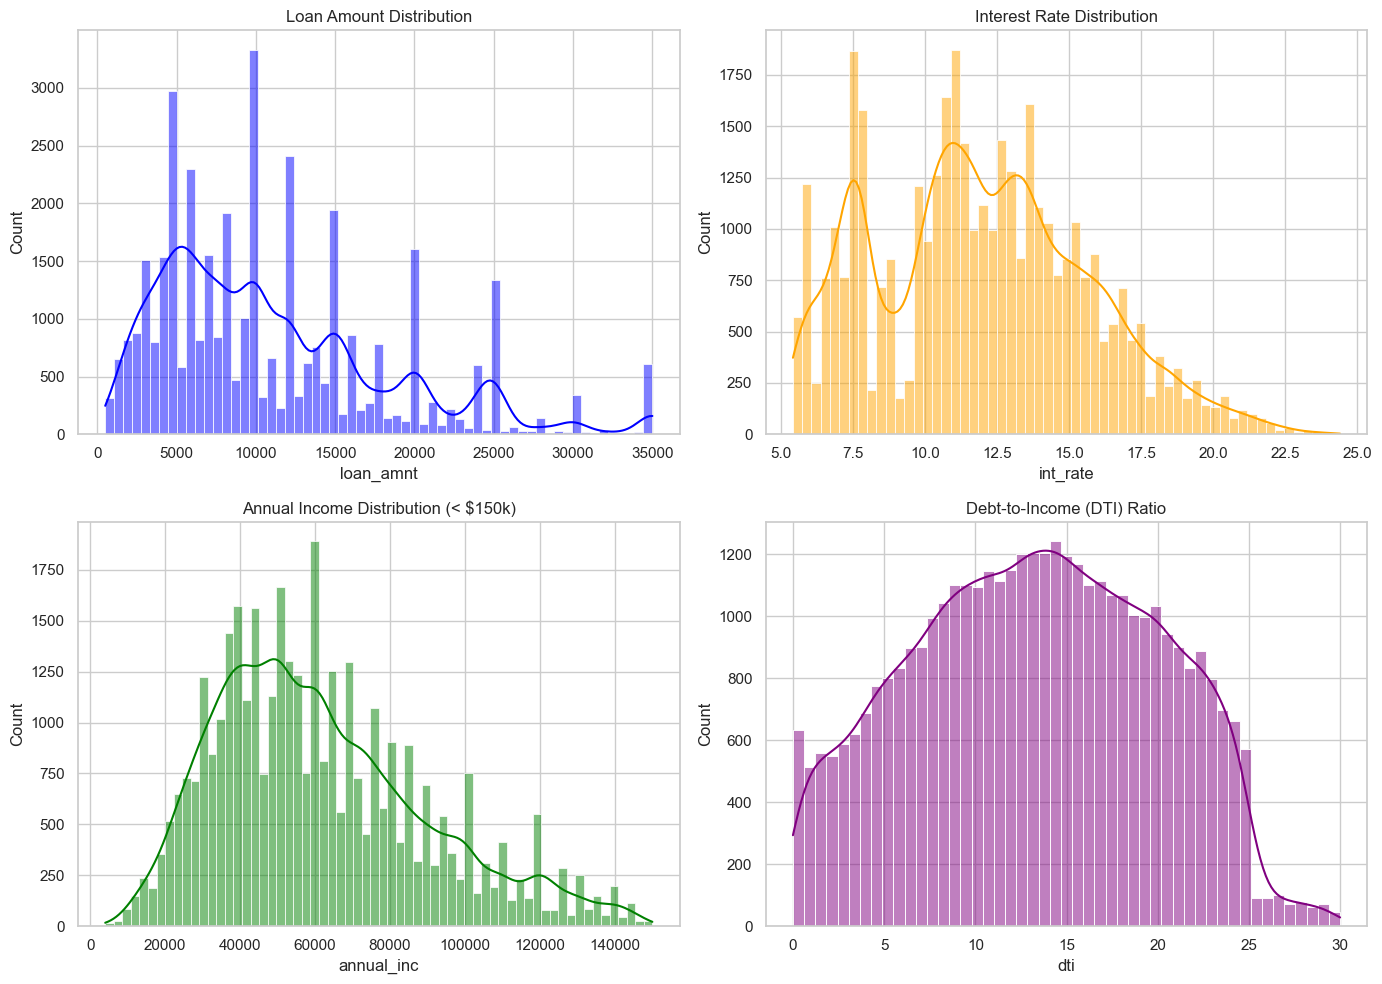

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loan Amount Distribution
sns.histplot(df_clean['loan_amnt'], kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Loan Amount Distribution')

# Interest Rate Distribution
sns.histplot(df_clean['int_rate'], kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Interest Rate Distribution')

# Annual Income Distribution (capped for display)
sns.histplot(df_clean[df_clean['annual_inc'] < 150000]['annual_inc'], kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Annual Income Distribution (< $150k)')

# DTI Ratio Distribution
sns.histplot(df_clean['dti'], kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Debt-to-Income (DTI) Ratio')

plt.tight_layout()
plt.show()


## 5. Category Delinquency Analysis
Analyze the default rate across categories such as Home Ownership and Loan Purpose.


/var/folders/q3/j6mhztqd0s700qmyt3rfc4pm0000gn/T/ipykernel_87402/1469641305.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='home_ownership', y='target', data=df_clean, ax=axes[0], palette='viridis', errorbar=None)
/var/folders/q3/j6mhztqd0s700qmyt3rfc4pm0000gn/T/ipykernel_87402/1469641305.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='target', y='purpose', data=df_clean, ax=axes[1], palette='rocket', errorbar=None)


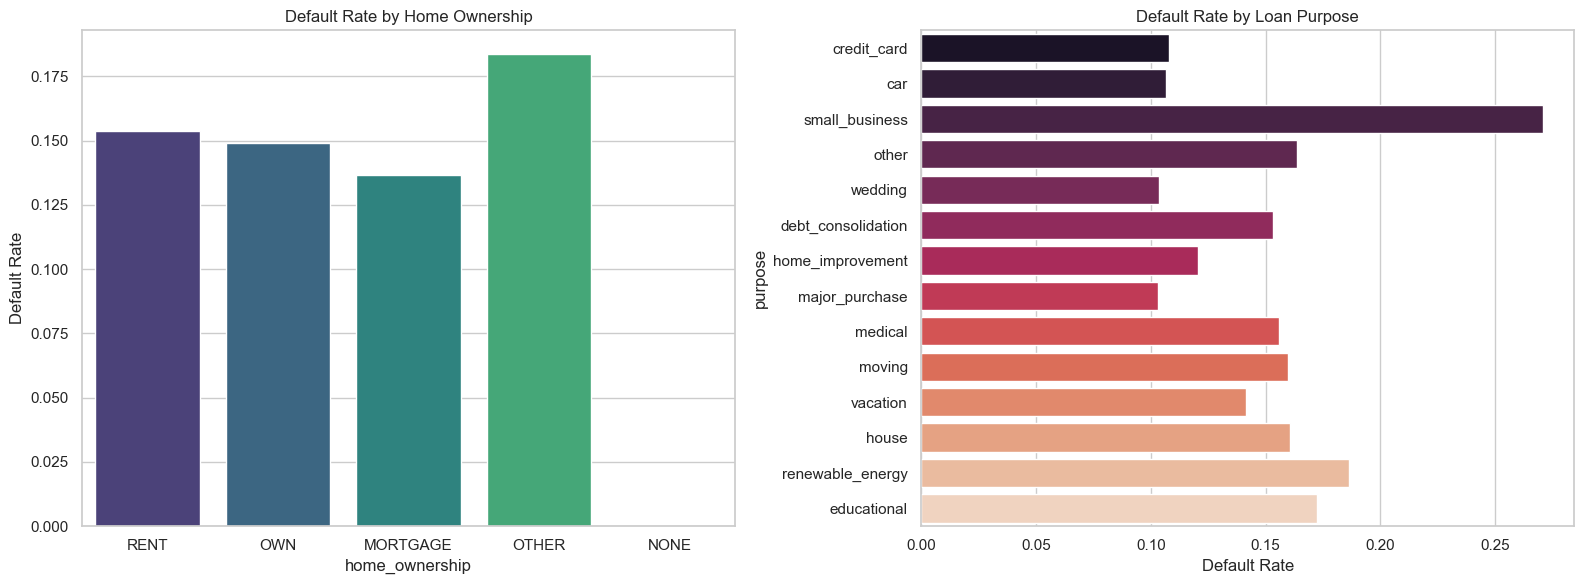

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default rate by Home Ownership
sns.barplot(x='home_ownership', y='target', data=df_clean, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Default Rate by Home Ownership')
axes[0].set_ylabel('Default Rate')

# Default rate by Loan Purpose
sns.barplot(x='target', y='purpose', data=df_clean, ax=axes[1], palette='rocket', errorbar=None)
axes[1].set_title('Default Rate by Loan Purpose')
axes[1].set_xlabel('Default Rate')

plt.tight_layout()
plt.show()
